# TT-04 — Logistic Regression

## Dự đoán nguy cơ bệnh tim

Mục tiêu:
- Xây dựng mô hình Logistic Regression.
- Dự đoán nguy cơ mắc bệnh tim.
- Giải thích mô hình bằng Odds Ratio.
- Đánh giá mô hình bằng Recall, Precision, ROC-AUC.
- Tìm ngưỡng dự đoán phù hợp với yêu cầu Recall >= 0.90.

## Đọc và làm sạch dữ liệu

In [1]:
import json
import os
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

pd.set_option("display.max_columns", 30)
print("Import thư viện thành công!")


Import thư viện thành công!


In [3]:
DATA_PATH = "../data/heart.csv"

df = pd.read_csv(DATA_PATH)
print("Kích thước ban đầu:", df.shape)

duplicate_count = df.duplicated().sum()
print("Số dòng trùng:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Kích thước sau khi xóa duplicate:", df.shape)
print("Kiểm chứng lại số duplicate còn lại:", df.duplicated().sum())

df.head()

Kích thước ban đầu: (1025, 14)
Số dòng trùng: 723
Kích thước sau khi xóa duplicate: (302, 14)
Kiểm chứng lại số duplicate còn lại: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Xác định biến

In [4]:
categorical_columns = [
    "cp", "restecg", "slope", "thal", "ca",   # nhiều mức
    "sex", "fbs", "exang",                     # nhị phân — cũng là phân loại
]

numeric_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

target_column = "target"

# Kiểm tra tường minh: không được sót cột nào
assert set(categorical_columns + numeric_columns + [target_column]) == set(df.columns), \
    "Có cột trong dữ liệu chưa được khai báo!"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Biến phân loại:", categorical_columns)
print("Biến số:", numeric_columns)
print("Biến mục tiêu:", target_column)
print("\nKích thước X:", X.shape, "| Kích thước y:", y.shape)

Biến phân loại: ['cp', 'restecg', 'slope', 'thal', 'ca', 'sex', 'fbs', 'exang']
Biến số: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Biến mục tiêu: target

Kích thước X: (302, 13) | Kích thước y: (302,)


##  EDA: tỉ lệ bệnh theo cp, theo nhóm tuổi, boxplot thalach theo target

TỈ LỆ BỆNH THEO CP
cp
0    0.272727
1    0.820000
2    0.790698
3    0.695652
Name: target, dtype: float64


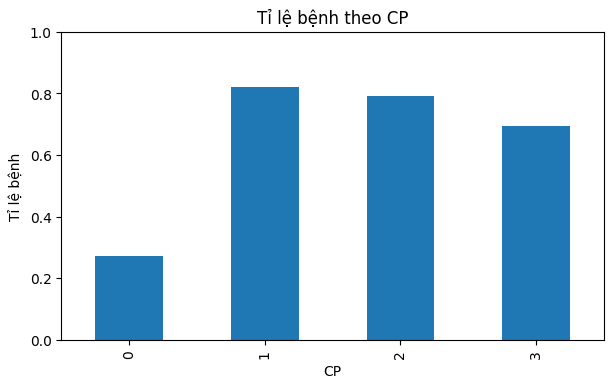

TỈ LỆ BỆNH THEO NHÓM TUỔI
age_group
<40      0.733333
40-49    0.694444
50-59    0.520000
60-69    0.400000
70+      0.600000
Name: target, dtype: float64


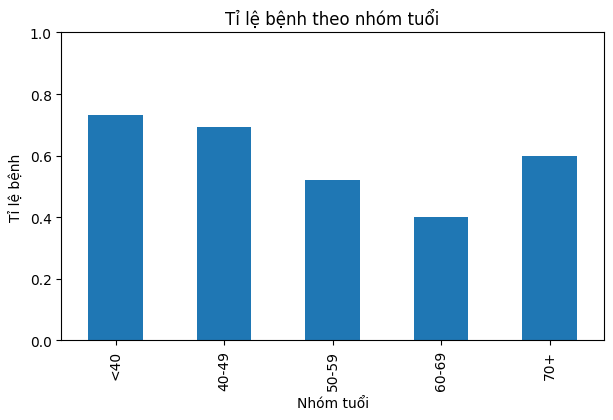

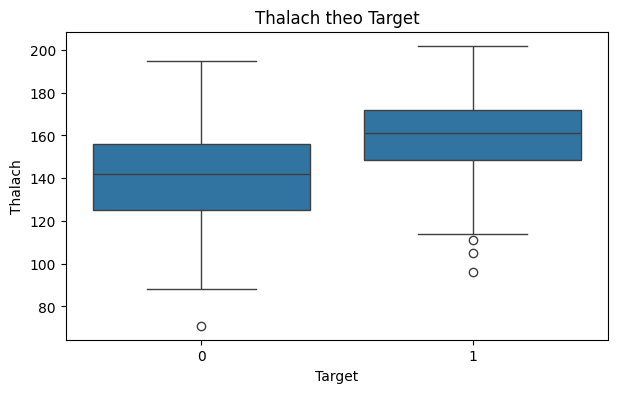

In [6]:
cp_rate = df.groupby("cp")["target"].mean()
print("TỈ LỆ BỆNH THEO CP")
print(cp_rate)

cp_rate.plot(kind="bar", figsize=(7, 4))
plt.title("Tỉ lệ bệnh theo CP")
plt.xlabel("CP")
plt.ylabel("Tỉ lệ bệnh")
plt.ylim(0, 1)
plt.show()

df["age_group"] = pd.cut(
    df["age"], bins=[0, 39, 49, 59, 69, 100],
    labels=["<40", "40-49", "50-59", "60-69", "70+"],
)
age_rate = df.groupby("age_group", observed=False)["target"].mean()
print("TỈ LỆ BỆNH THEO NHÓM TUỔI")
print(age_rate)

age_rate.plot(kind="bar", figsize=(7, 4))
plt.title("Tỉ lệ bệnh theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỉ lệ bệnh")
plt.ylim(0, 1)
plt.show()

df = df.drop(columns=["age_group"])

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="target", y="thalach")
plt.title("Thalach theo Target")
plt.xlabel("Target")
plt.ylabel("Thalach")
plt.show()

## Chia Train/ Validation / Test

In [7]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 181 | Validation: 60 | Test: 61


## PIPELINE

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns),
        ("numeric", StandardScaler(), numeric_columns),
    ]
)

logistic_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_pipeline.fit(X_train, y_train)

print("Train Logistic Regression thành công!")
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Train Logistic Regression thành công!
X_train: (181, 13) | X_val: (60, 13) | X_test: (61, 13)


## BASELINE (Dummy Classifier)

In [12]:
def evaluate(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
    }
    print(f"[{name}]")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics


dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_metrics = evaluate(dummy_model, X_test, y_test, "DUMMY CLASSIFIER (test)")
logreg_metrics = evaluate(logistic_pipeline, X_test, y_test, "LOGISTIC REGRESSION (test, ngưỡng mặc định 0.5)")

[DUMMY CLASSIFIER (test)]
  accuracy: 0.5410
  precision: 0.5410
  recall: 1.0000
  f1: 0.7021
  roc_auc: 0.5000
[LOGISTIC REGRESSION (test, ngưỡng mặc định 0.5)]
  accuracy: 0.8361
  precision: 0.8710
  recall: 0.8182
  f1: 0.8438
  roc_auc: 0.9286


## Bảng ODDS RATIO

In [13]:
def compute_odds_table(pipeline):
    trained_model = pipeline.named_steps["model"]
    coefficients = trained_model.coef_[0]
    feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
    odds_ratio = np.exp(coefficients)

    table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Odds_Ratio": odds_ratio,
    })
    return table.sort_values("Odds_Ratio", ascending=False)


odds_table = compute_odds_table(logistic_pipeline)
print("BẢNG ODDS RATIO")
display(odds_table)

BẢNG ODDS RATIO


,Feature,Coefficient,Odds_Ratio
1,categorical__cp_2,1.594733,4.927012
2,categorical__cp_3,1.106734,3.024466
0,categorical__cp_1,0.683276,1.980355
3,categorical__restecg_1,0.635337,1.887658
8,categorical__thal_2,0.597466,1.817508
20,numeric__thalach,0.588072,1.800514
6,categorical__slope_2,0.524726,1.689997
13,categorical__ca_4,0.432139,1.540549
7,categorical__thal_1,0.298131,1.347339
17,numeric__age,0.195648,1.216099


## So sánh L1 và L2

In [17]:
model_l1 = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=42)),
])
model_l2 = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(penalty="l2", max_iter=2000, random_state=42)),
])

model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

l1_metrics = evaluate(model_l1, X_test, y_test, "L1 (test)")
print()
l2_metrics = evaluate(model_l2, X_test, y_test, "L2 (test)")

coef_l1 = model_l1.named_steps["model"].coef_[0]
zero_count = int(np.sum(np.isclose(coef_l1, 0)))
print(f"\nSố feature L1 đưa hệ số về 0: {zero_count}/{len(coef_l1)}")

[L1 (test)]
  accuracy: 0.8361
  precision: 0.8710
  recall: 0.8182
  f1: 0.8438
  roc_auc: 0.9232

[L2 (test)]
  accuracy: 0.8361
  precision: 0.8710
  recall: 0.8182
  f1: 0.8438
  roc_auc: 0.9286

Số feature L1 đưa hệ số về 0: 5/22


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Vẽ đường ROC và Precision-Recall

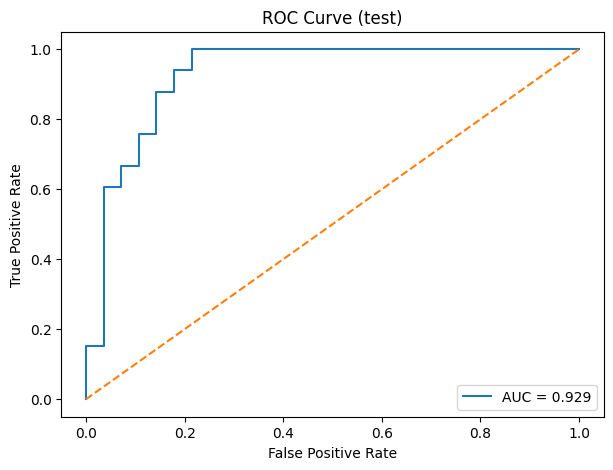

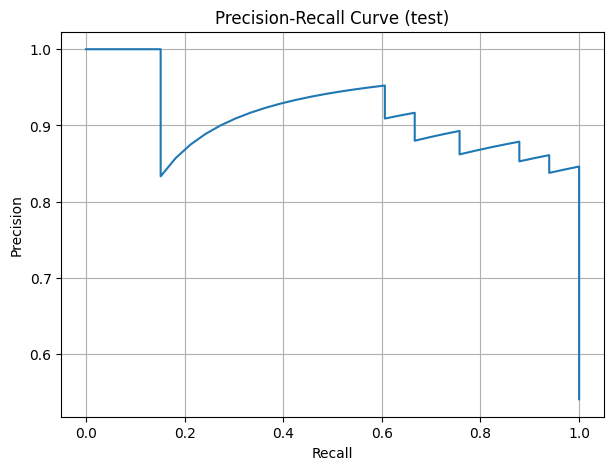

ROC-AUC (test): 0.9285714285714286


In [18]:
y_test_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_test_proba)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_test:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (test)")
plt.legend()
plt.show()

precision_values_test, recall_values_test, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_values_test, precision_values_test)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (test)")
plt.grid()
plt.show()

print("ROC-AUC (test):", auc_test)

## Chọn ngưỡng đạt recall ≥ 0,90, ghi lại precision tương ứng

In [21]:
target_recall = 0.90

y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_val, y_val_proba)

valid_idx = np.where(recall_values[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    idx = valid_idx[-1]  # ngưỡng CAO NHẤT vẫn thoả ràng buộc recall
    best_threshold = float(pr_thresholds[idx])
    best_precision_val = float(precision_values[idx])
    best_recall_val = float(recall_values[idx])
    print(f"Ngưỡng chọn (trên validation): {best_threshold:.4f}")
    print(f"Precision (validation): {best_precision_val:.4f}")
    print(f"Recall (validation):    {best_recall_val:.4f}")
else:
    best_threshold = 0.5
    print(f"Không tìm được ngưỡng nào đạt recall >= {target_recall} trên validation, dùng 0.5")

y_pred_threshold = (y_test_proba >= best_threshold).astype(int)

precision_thresh = precision_score(y_test, y_pred_threshold, zero_division=0)
recall_thresh = recall_score(y_test, y_pred_threshold, zero_division=0)
n_flagged = int(y_pred_threshold.sum())
base_rate = y_test.mean()

print(f"KẾT QUẢ TRÊN TEST với ngưỡng {best_threshold:.4f}:")
print(f"  Precision: {precision_thresh:.4f}")
print(f"  Recall:    {recall_thresh:.4f}")
print(f"  Số bệnh nhân bị gắn cờ dương tính: {n_flagged}/{len(y_test)} "
      f"(tỉ lệ nền dương tính trong test: {base_rate:.4f})")

if n_flagged >= 0.95 * len(y_test) or abs(precision_thresh - base_rate) < 0.01:
    print("  CẢNH BÁO: ngưỡng gần như flag TOÀN BỘ bệnh nhân là dương tính — "
          "model không cho thêm thông tin gì so với đoán 'ai cũng bệnh' ở "
          "ngưỡng này.")
else:
    print("  OK: precision cao hơn hẳn tỉ lệ nền -> ngưỡng thực sự có ý nghĩa "
          "phân loại, không suy biến.")

Ngưỡng chọn (trên validation): 0.2255
Precision (validation): 0.7895
Recall (validation):    0.9091
KẾT QUẢ TRÊN TEST với ngưỡng 0.2255:
  Precision: 0.8378
  Recall:    0.9394
  Số bệnh nhân bị gắn cờ dương tính: 37/61 (tỉ lệ nền dương tính trong test: 0.5410)
  OK: precision cao hơn hẳn tỉ lệ nền -> ngưỡng thực sự có ý nghĩa phân loại, không suy biến.


## Kiểm tra ĐA CỘNG TUYẾN bằng VIF 

In [22]:
X_vif = preprocessor.fit_transform(X_train)
if hasattr(X_vif, "toarray"):
    X_vif = X_vif.toarray()
vif_features = preprocessor.get_feature_names_out()

vif_table = pd.DataFrame({
    "Feature": vif_features,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

n_inf = int(np.isinf(vif_table["VIF"]).sum())
print(f"Số dòng VIF = inf: {n_inf} (kỳ vọng 0 sau khi thêm drop='first')")

print("\nBẢNG VIF")
display(vif_table)

print("\nCÁC FEATURE CÓ VIF > 10")
display(vif_table[vif_table["VIF"] > 10])

Số dòng VIF = inf: 0 (kỳ vọng 0 sau khi thêm drop='first')

BẢNG VIF


,Feature,VIF
8,categorical__thal_2,15.730590
6,categorical__slope_2,13.547981
9,categorical__thal_3,11.259381
5,categorical__slope_1,10.732394
14,categorical__sex_1,4.024462
7,categorical__thal_1,2.762809
1,categorical__cp_2,2.382419
3,categorical__restecg_1,2.313281
21,numeric__oldpeak,2.083245
16,categorical__exang_1,2.056947



CÁC FEATURE CÓ VIF > 10


,Feature,VIF
8,categorical__thal_2,15.730590
6,categorical__slope_2,13.547981
9,categorical__thal_3,11.259381
5,categorical__slope_1,10.732394


## So sánh 3 mô hình ( SVM, Random Forest, Logistic Regression )

In [23]:
svm = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(probability=True, random_state=42)),
])
rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
])

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm,
    "Random Forest": rf,
}

results = []
for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
        roc_auc_score(y_test, prob),
    ])

comparison = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)
display(comparison)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.836066,0.870968,0.818182,0.843750,0.928571
1,SVM,0.852459,0.875000,0.848485,0.861538,0.924242
2,Random Forest,0.836066,0.896552,0.787879,0.838710,0.906385


## Viết giải thích cho một bệnh nhân cụ thể

In [24]:
patient = X_test.iloc[[0]]

prob = logistic_pipeline.predict_proba(patient)[0, 1]
prediction = logistic_pipeline.predict(patient)[0]

print("THÔNG TIN BỆNH NHÂN:")
display(patient)

print(f"\nXác suất mắc bệnh: {prob * 100:.2f}%")

if prediction == 1:
    print("KẾT LUẬN: Mô hình dự đoán bệnh nhân CÓ nguy cơ mắc bệnh.")
else:
    print("KẾT LUẬN: Mô hình dự đoán bệnh nhân KHÔNG có nguy cơ mắc bệnh.")

THÔNG TIN BỆNH NHÂN:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
114,57,1,0,152,274,0,1,88,1,1.2,1,1,3



Xác suất mắc bệnh: 0.55%
KẾT LUẬN: Mô hình dự đoán bệnh nhân KHÔNG có nguy cơ mắc bệnh.


## Lưu báo cáo

Đã lưu ../reports/vif_table.csv


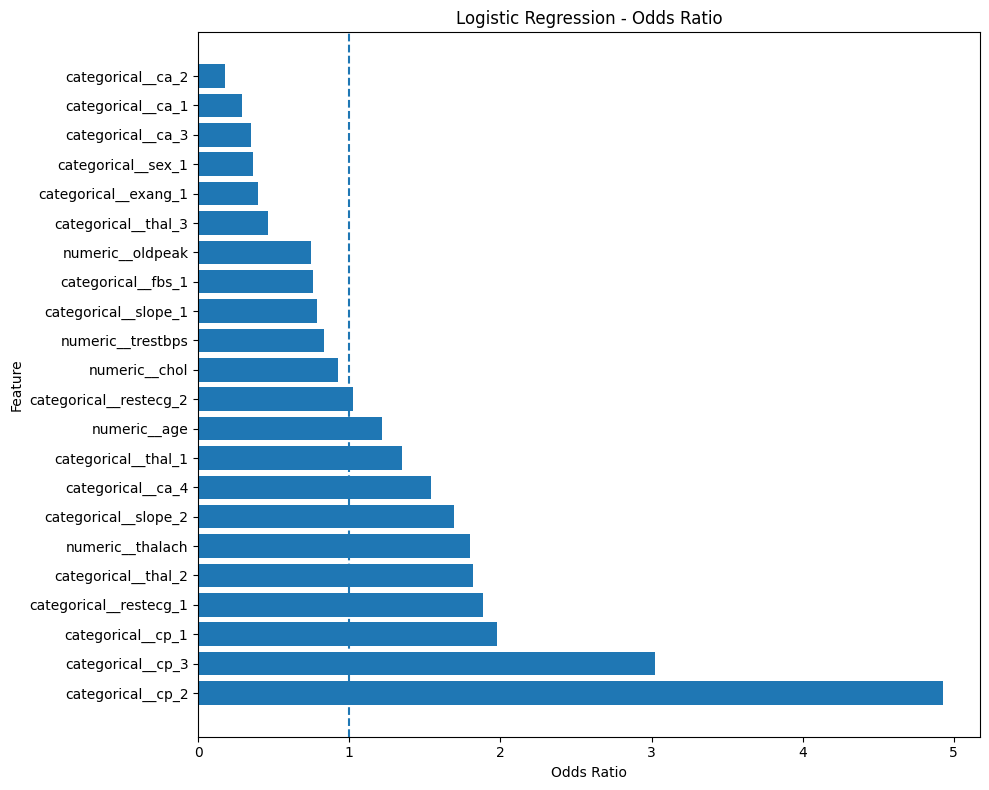

Đã lưu ../reports/odds_ratio.png


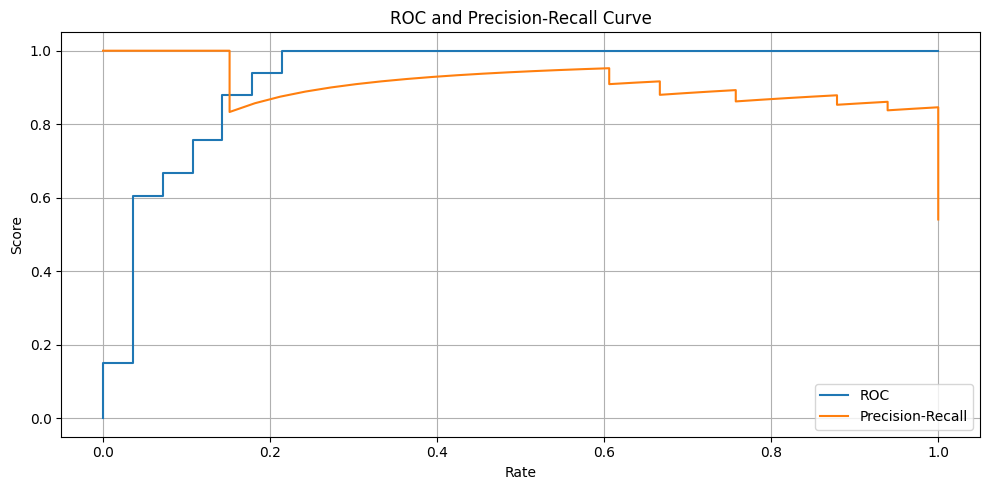

Đã lưu ../reports/roc_pr_curve.png


In [26]:
# --- Lưu VIF ---
vif_table.to_csv("../reports/vif_table.csv", index=False)
print("Đã lưu ../reports/vif_table.csv")

# --- Vẽ và lưu Odds Ratio (dùng lại bảng đã tính ở mục 7) ---
plt.figure(figsize=(10, 8))
plt.barh(odds_table["Feature"], odds_table["Odds_Ratio"])
plt.axvline(1, linestyle="--")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.title("Logistic Regression - Odds Ratio")
plt.tight_layout()
plt.savefig("../reports/odds_ratio.png", dpi=300)
plt.show()
print("Đã lưu ../reports/odds_ratio.png")

# --- Lưu ROC + Precision-Recall (trên test) ---
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
precision_final, recall_final, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_final, precision_final, label="Precision-Recall")
plt.xlabel("Rate")
plt.ylabel("Score")
plt.title("ROC and Precision-Recall Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("../reports/roc_pr_curve.png", dpi=300)
plt.show()
print("Đã lưu ../reports/roc_pr_curve.png")



##  Lưu metrics.json và model

In [27]:
metrics_summary = {
    "data": {
        "rows_before_dedup": int(duplicate_count + len(df)),
        "duplicates_removed": int(duplicate_count),
        "rows_after_dedup": int(len(df)),
    },
    "dummy_baseline": dummy_metrics,
    "logistic_regression_default_threshold": logreg_metrics,
    "l1": l1_metrics,
    "l2": l2_metrics,
    "l1_coefficients_zeroed": zero_count,
    "threshold_tuning": {
        "target_recall": target_recall,
        "chosen_threshold": best_threshold,
        "precision_on_validation": best_precision_val,
        "recall_on_validation": best_recall_val,
        "precision_on_test": precision_thresh,
        "recall_on_test": recall_thresh,
        "n_flagged_positive_on_test": n_flagged,
        "test_set_size": len(y_test),
    },
    "vif_max_finite": float(vif_table["VIF"].replace([np.inf], np.nan).max()),
    "vif_inf_count": n_inf,
}

with open("../reports/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)
print("Đã lưu ../reports/metrics.json")

joblib.dump(logistic_pipeline, "../models/logreg_pipeline.joblib")
print("Đã lưu ../models/logreg_pipeline.joblib")

print("\nHOÀN TẤT!")

Đã lưu ../reports/metrics.json
Đã lưu ../models/logreg_pipeline.joblib

HOÀN TẤT!
